In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:100% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# ※ ①naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 각각 500건씩 검색(re ? )후 백업 ->  ②품사태깅 백업 -> ③명사만 추출 -> ④빈도분석(DataFrame) 후 백업-> ⑤빈도 시각화(워드클라우드, Text) ->⑥ Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title + ' ' + description(total_text)

In [2]:
# pip install python-dotenv (환경변수를 쓰기 위한 라이브러리)
# pip install python-decouple (주피터 환경에서는 안 될 수도 있음)
import os
os.getcwd() # 현재 작업디렉토리

'D:\\ai_x\\source\\07_자연어처리'

In [3]:
%ls .env

 D 드라이브의 볼륨: 새 볼륨
 볼륨 일련 번호: BE7A-ADFF

 D:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:50                56 .env
               1개 파일                  56 바이트
               0개 디렉터리  487,593,365,504 바이트 남음


In [6]:
from dotenv import load_dotenv
load_dotenv()

# print(os.getenv('Client_ID'))
# print(os.getenv('Client_Secret'))

True

In [7]:
from decouple import config
# print(config('Client_ID'))
# print(config('Client_Secret'))

In [8]:
# 네이버 개발자 센터 document에 있는 내용 그냥 그대로 가져와 봄
import os
import sys
import urllib.request
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
encText = urllib.parse.quote("경주 여행")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:500])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Thu, 19 Jun 2025 11:12:37 +0900",
	"total":931084,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"<b>경주 여행<\/b>코스 루지월드 해방감을 느꼈어요",
			"link":"https:\/\/blog.naver.com\/sangil00\/223903211939",
			"description":"오랜만에 활기차고 건강하게 하루를 보낼 수 있었고요. 날씨 좋은 계절에 경주를 방문하신다면 루지월드를 꼭 <b>경주 여행<\/b>코스에 넣어보시길 바라요. 정말 후회 없는 경험이 될 거예요. #<b>경주여행<\/b>코스 #루지월드",
			"bloggername":"길을 찾는 즐거움_거칠부",
			"bloggerlink":"blog.naver.com\/sangil00",
			"postdate":"20250618"
		},
		{
			"title":"당일치기 <


In [9]:
# 패키지 import
import requests
import time
import os
import json # response 텍스트를 json 딕셔너리로
from html import unescape # description에 있는 &lt;(특수문자)을 <으로 변경, &gt;-> >
import pandas as pd
import re

In [10]:
query = "경주 여행"
start = 1
url = f"https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}"
headers = {"X-Naver-Client-Id":client_id,
           "X-Naver-Client-Secret":client_secret}
response = requests.get(url, headers=headers)
items = json.loads(response.text)['items']
print(len(items))
print(items[51],items[58])

100
{'title': '6월 <b>경주여행</b>', 'link': 'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=446801776&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8', 'description': '제가 6월달에 엄마아빠랑 언니랑 <b>경주여행</b>을 가는데요 갈곳 추천해주세요.너무 유명한 곳은 아니였음 하네요. (예... <b>경주여행</b>을 계획하시는 것 같네요. 저도 여러분들이 즐길 수 있는 장소와 활동을 추천해드릴게요. ## 1. 경주 월드컵... '} {'title': '<b>경주여행</b>(숙소추천)', 'link': 'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8', 'description': '안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤 <b>경주여행</b>을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ &lt; &quot; &quot; &quot;&quot; &quot; 즐거운 <b>경주여행</b> 되시기... '}


In [11]:
item = items[58]
title = item['title']
link = item['link']
description = item['description']
print(title, link, description, sep='\n')

<b>경주여행</b>(숙소추천)
https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8
안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤 <b>경주여행</b>을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ &lt; &quot; &quot; &quot;&quot; &quot; 즐거운 <b>경주여행</b> 되시기... 


In [12]:
# 위의 title의 <b>태그 없애기, description의 <b>태그 없애고 html의 특수문자 없애기
item = items[58]
title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
link = item['link']
description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
print(title, link, description, sep='\n')

 경주여행 (숙소추천)
https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=460129729&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8
안녕하세요 경기도권에 사는 사람입니다 내년 1월 중순쯤  경주여행 을 갈 예정입니다 인원은 엄마3명과 초등5명 총 8명... 근데 추운 겨울 걷는건 비추입니다 ㅠㅠ 가까운 거리도 택시 타고 다니세요^^ < " " "" " 즐거운  경주여행  되시기... 


In [13]:
import re
description = "#추억여행 ####ktx 타고 @짱@ ㅎㅎㅎ ㅠㅠ ㅋㅋ"

# 정규표현식: 알파벳, 숫자, 한글만 남기고 나머지는 제거
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
description = re.sub('\s+', ' ', description)
print(description)

 추억여행 ktx 타고 짱 


In [14]:
# 네이버 API 계정 정보
from dotenv import load_dotenv
import os
load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
queries = ['전주 여행', '경주 여행']
max_start = 5

#### 크롤링저장 방법1

In [15]:
# 방법1
def get_search_element_save(query, start):
    headers = {'X-Naver-Client-Id':client_id,
           'X-Naver-Client-Secret':client_secret}
    url = f'https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start+1}'
    response = requests.get(url, headers=headers)
    items = json.loads(response.text)['items']
    for i, item in enumerate(items):
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
#         print('수정전 :', description)
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
#         print('수정후 :', description)
        # print(query, (start*100+i+1), title, link, description, title+' ' +description)
        with open(file_name, 'a', encoding='utf-8') as file:
            file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format(query, 
                                                         (start-1)*100+i+1,
                                                         title,
                                                         link,
                                                         description, 
                                                         title + ' ' +description))

In [16]:
# 데이터를 저장할 파일 생성 (naver_kin.txt)하고 title 저장(header저장)
file_name = 'data/naver_kin.csv'
with open(file_name, 'w', encoding='utf-8') as file:
    file.write('{}\t{}\t{}\t{}\t{}\t{}\n'.format('query', 
                            'no','title','link', 'description', 'total_text'))

In [17]:
for query in queries:
    for start in range(1, max_start+1):
        print(start, query, '읽는 중')
        get_search_element_save(query, start)
        time.sleep(0.5)

1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
5 전주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중
5 경주 여행 읽는 중


#### 크롤링저장 방법 2

In [53]:
# 방법2 ( 수업시간 내용과 동일 )
def get_search_element_return(query, start):
    headers = {'X-Naver-Client-Id':client_id,
           'X-Naver-Client-Secret':client_secret}
    url = f'https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}'
    response = requests.get(url, headers=headers)
    items = json.loads(response.text)['items']
    result = []
    for i, item in enumerate(items):
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
#         print('수정전 :', description)
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
#         print('수정후 :', description)
        # print(query, (start*100+i+1), title, link, description, title+' ' +description)
        result.append({'query':query,
                      'no':(start-1)*100+i+1,
                      'title':title,
                      'link':link,
                      'description':description,
                      'total_text':title+ ' ' + description})
    return result

In [54]:
result_total = []
for query in queries:
    for start in range(max_start):
        print(start, query, '읽는 중')
        result_total.extend(get_search_element_return(query, start))
        time.sleep(0.5)
df = pd.DataFrame(result)
df.to_csv('data/naver_kin.csv', index=False, sep='\t')

0 전주 여행 읽는 중
1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
0 경주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중


# 2. 품사 태깅 저장

In [19]:
import pandas as pd
df = pd.read_csv('data/naver_kin.csv', sep='\t')
df.head(2)

,query,no,title,link,description,total_text
0,전주 여행,1,전주여행 갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2...,전주여행 갈려고하는데요! 전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔...
1,전주 여행,2,전주 1박 2일 여행 관련 질문~,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주 여행 을 계획하고 계시다니 정말 좋은 선택을 하셨네요 전주는 한옥마을과 함께...,전주 1박 2일 여행 관련 질문~ 전주 여행 을 계획하고 계시다니 정말 좋...


In [20]:
df_list = df[['query','no','total_text']].values.tolist()
df_list[::500]

[['전주 여행',
  1,
  ' 전주여행 갈려고하는데요!  전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2박3일여행인데 얼마정도갖고가면좋을까요 그리고 맛집같은거 카페같은거 추천해주세요 안녕하세요 전주 여행 계획 중이시네요 한옥마을 근처 '],
 ['경주 여행',
  1,
  '1박2일  경주 여행  일정 짜주세요 1박2일 경주 여행 일정 짜주세요 질문자님 경주에서의 1박 2일 여행을 계획 중이시군요 특히 소록스테이 에서의 아래에 경주 여행 일정을 간략히 정리해 드릴게요 1박 2일 경주 여행 일정 Day 1 감성 가득한 경주 탐방 10 30 ']]

In [21]:
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
stopwords = ['전주','경주','여행']
select_pos = ['NNG', 'NNP'] 

In [23]:
postagged_lst = []
for i, row in enumerate(df_list):
    query = row[0]
    no = row[1]
    text = row[2]
    text_pos = analyzer.pos(text)
    # analyzer가 MeCab이 아닐 경우 시간이 좀 걸려서 250개마다 로그 출력
#     if i%250==0:
#         print("{}의 {}번째 품사태깅 결과 {}개 저장중".format(query, 
#                                                 no, 
#                                                 len(text_pos), end='\n\n'))
    for token, pos in text_pos:
        # if token not in stopwords and pos in select_pos: 라고 하면 명사만 추출
        if token not in stopwords and len(token)>1: # 모든 품사를 우선 다 넣고 나중에 빼려면
            postagged_lst.append({'query':query,
                                 'no':no,
                                 'token':token,
                                 'pos':pos})
df_postagged = pd.DataFrame(postagged_lst)
df_postagged

,query,no,token,pos
0,전주 여행,1,갈려고,VV+EC
1,전주 여행,1,는데요,EF
2,전주 여행,1,갈려고,VV+EC
3,전주 여행,1,는데요,EC
4,전주 여행,1,사람,NNG
...,...,...,...,...
24190,경주 여행,500,동시,NNG
24191,경주 여행,500,10,SN
24192,경주 여행,500,버스,NNG
24193,경주 여행,500,이용,NNG


In [24]:
df_postagged.to_csv('data/naver_kin_pos.csv', index=False, sep='\t')

# 3. 명사만 추출 

In [25]:
df_postagged = pd.read_csv('data/naver_kin_pos.csv', sep='\t')

In [26]:
select_pos = ['NNG', 'NNP'] 

In [27]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(['NNP', 'NNG']),
                            ['query', 'token','pos']]
df_nouns.head()

,query,token,pos
4,전주 여행,사람,NNG
7,전주 여행,호텔,NNG
8,전주 여행,가격,NNG
11,전주 여행,얼마,NNG
12,전주 여행,정도,NNG


In [28]:
df_nouns.to_csv('data/naver_kin_pos_nouns.csv', index=False, sep='\t')

# 4.빈도분석(DataFrame) 후 백업

In [29]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t')
df_nouns.shape

(14094, 3)

In [30]:
df_nouns.iloc[::5000]

,query,token,pos
0,전주 여행,사람,NNG
5000,전주 여행,호수,NNG
10000,경주 여행,답변,NNG


In [31]:
df_nouns.groupby(['query','token'], as_index=False)['pos'].count()

,query,token,pos
0,경주 여행,가격,10
1,경주 여행,가능,23
2,경주 여행,가본적,5
3,경주 여행,가성,5
4,경주 여행,가시,5
...,...,...,...
877,전주 여행,환급,5
878,전주 여행,회관,5
879,전주 여행,휴가,5
880,전주 여행,휴무,5


In [32]:
df_token_grp = df_nouns.groupby('query')['token'].value_counts()
df_token_grp

query  token
경주 여행  코스       452
       추천       398
       계획       155
       숙소       139
       질문       118
               ... 
전주 여행  자연         2
       찜질방        2
       내용         1
       야시장        1
       토대         1
Name: token, Length: 882, dtype: int64

In [33]:
df_token_grp = df_token_grp.reset_index(name='token_count')
df_token_grp.head()

,query,token,token_count
0,경주 여행,코스,452
1,경주 여행,추천,398
2,경주 여행,계획,155
3,경주 여행,숙소,139
4,경주 여행,질문,118


#### merge 방법

In [34]:
# 전주 여행과 경우 여행 여행 빈도 추출
import numpy as np
a = pd.DataFrame([['단어1', 90],
                 ['단어2',80]], columns=['단어','경주빈도'])
b = pd.DataFrame([['단어1', 99],
                 ['단어3',81]], columns=['단어','전주빈도'])
display(a)
display(b)
ab = pd.merge(a, b, 
         how='outer', # inner(공통), left, right, outer
         on='단어')   # 두 프레임을 어떤 열 기준으로 합칠지 지정
#pd.concat([a, b], axis=1)
ab.fillna(0, inplace=True)
ab['경주빈도'] = ab['경주빈도'].astype(np.int16)
ab['전주빈도'] = ab['전주빈도'].astype('int')
ab.info()

,단어,경주빈도
0,단어1,90
1,단어2,80


,단어,전주빈도
0,단어1,99
1,단어3,81


<class 'pandas.core.frame.DataFrame'>
Int64Index: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   단어      3 non-null      object
 1   경주빈도    3 non-null      int16 
 2   전주빈도    3 non-null      int32 
dtypes: int16(1), int32(1), object(1)
memory usage: 66.0+ bytes


In [35]:
df_gj = df_token_grp.loc[df_token_grp['query']=='경주 여행', ['token','token_count']]
df_jj = df_token_grp.loc[df_token_grp['query']=='전주 여행', ['token','token_count']]
df_gj.shape, df_jj.shape

((467, 2), (415, 2))

In [36]:
df_gj.head()

,token,token_count
0,코스,452
1,추천,398
2,계획,155
3,숙소,139
4,질문,118


In [37]:
df_jj.head()

,token,token_count
467,코스,485
468,여수,351
469,주달,306
470,추천,299
471,맛집,288


In [38]:
df_mrg = pd.merge(df_gj, df_jj, how='outer', on='token')
print(df_mrg.shape)
df_mrg

(711, 3)


,token,token_count_x,token_count_y
0,코스,452.0,485.0
1,추천,398.0,299.0
2,계획,155.0,60.0
3,숙소,139.0,60.0
4,질문,118.0,78.0
...,...,...,...
706,일본,NaN,3.0
707,동네,NaN,2.0
708,찜질방,NaN,2.0
709,야시장,NaN,1.0


In [39]:
df_mrg.columns = ['token','경주빈도','전주빈도']
df_mrg.fillna(0, inplace=True)
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype('int')
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int64) # 'int64'
df_mrg

,token,경주빈도,전주빈도
0,코스,452,485
1,추천,398,299
2,계획,155,60
3,숙소,139,60
4,질문,118,78
...,...,...,...
706,일본,0,3
707,동네,0,2
708,찜질방,0,2
709,야시장,0,1


In [40]:
df_mrg['빈도합'] = df_mrg['경주빈도'] + df_mrg['전주빈도']
df_mrg['전주비율'] = df_mrg['전주빈도'] / df_mrg['빈도합']
df_mrg['경주비율'] = df_mrg['경주빈도'] / df_mrg['빈도합']
df_mrg.head(10)

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,코스,452,485,937,0.517609,0.482391
1,추천,398,299,697,0.428981,0.571019
2,계획,155,60,215,0.279070,0.720930
3,숙소,139,60,199,0.301508,0.698492
4,질문,118,78,196,0.397959,0.602041
5,일정,114,81,195,0.415385,0.584615
6,답변,105,57,162,0.351852,0.648148
7,부탁,105,74,179,0.413408,0.586592
8,맛집,100,288,388,0.742268,0.257732
9,가족,95,20,115,0.173913,0.826087


In [41]:
df_mrg_srt = df_mrg.sort_values(by=['빈도합'], ascending=False)
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,코스,452,485,937,0.517609,0.482391
1,추천,398,299,697,0.428981,0.571019
8,맛집,100,288,388,0.742268,0.257732
467,여수,0,351,351,1.000000,0.000000
468,주달,0,306,306,1.000000,0.000000
...,...,...,...,...,...,...
458,감포,1,0,1,0.000000,1.000000
459,동시,1,0,1,0.000000,1.000000
460,봉길,1,0,1,0.000000,1.000000
461,소록,1,0,1,0.000000,1.000000


In [42]:
df_mrg_srt['전주비율'] = df_mrg_srt['전주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt['경주비율'] = df_mrg_srt['경주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,코스,452,485,937,51.76%,48.24%
1,추천,398,299,697,42.90%,57.10%
8,맛집,100,288,388,74.23%,25.77%
467,여수,0,351,351,100.00%,0.00%
468,주달,0,306,306,100.00%,0.00%
...,...,...,...,...,...,...
458,감포,1,0,1,0.00%,100.00%
459,동시,1,0,1,0.00%,100.00%
460,봉길,1,0,1,0.00%,100.00%
461,소록,1,0,1,0.00%,100.00%


In [43]:
df_mrg_srt.reset_index(drop=True, inplace=True)
df_mrg_srt

,token,경주빈도,전주빈도,빈도합,전주비율,경주비율
0,코스,452,485,937,51.76%,48.24%
1,추천,398,299,697,42.90%,57.10%
2,맛집,100,288,388,74.23%,25.77%
3,여수,0,351,351,100.00%,0.00%
4,주달,0,306,306,100.00%,0.00%
...,...,...,...,...,...,...
706,감포,1,0,1,0.00%,100.00%
707,동시,1,0,1,0.00%,100.00%
708,봉길,1,0,1,0.00%,100.00%
709,소록,1,0,1,0.00%,100.00%


In [44]:
df_mrg_srt.to_csv('data/naver_kin_pos_nouns_count.txt', sep='\t')

# 5. 빈도 시각화(워드클라우드, Text)

In [45]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t') # 명사만 뽑아놓은 파일로드
print(df_nouns.shape)
df_nouns.iloc[::3000]

(14094, 3)


,query,token,pos
0,전주 여행,사람,NNG
3000,전주 여행,덕진구,NNP
6000,전주 여행,한옥마을,NNP
9000,경주 여행,여유,NNG
12000,경주 여행,개별,NNG


In [46]:
df_nouns['pos'].unique()

array(['NNG', 'NNP'], dtype=object)

In [47]:
df_gj_noun = df_nouns.loc[df_nouns['query']=='경주 여행','token'].to_list()
df_jj_noun = df_nouns.loc[df_nouns['query']=='전주 여행','token'].to_list()
print(df_gj_noun[:5])
print(df_jj_noun[:5])
gj = ' '.join(df_gj_noun)
jj = ' '.join(df_jj_noun)
print(gj[:10])
print(jj[:10])

['일정', '일정', '문자', '계획', '소록']
['사람', '호텔', '가격', '얼마', '정도']
일정 일정 문자 계
사람 호텔 가격 얼


In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
color_map = "Blues"
font_path = 'data/NanumPenScript-Regular.ttf'

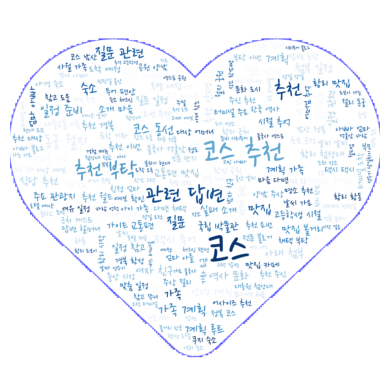

In [49]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/heart.jpg'))
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap=color_map,
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=200,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=777,
    font_path = font_path,
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
).generate(gj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [50]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/naver_kin_경주.jpg')

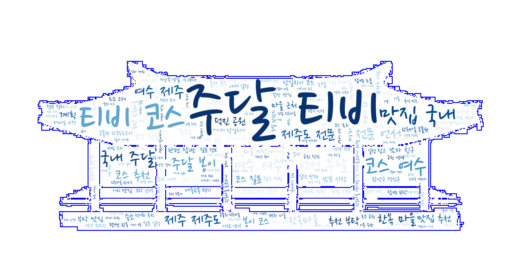

In [51]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/korea-house-black-fill.png'))
불용어 = set(['여행'])
wordcloud = WordCloud(
    background_color='white',
    colormap=color_map,
    collocations=True, # 특정단어가 자주 같이 나오면 같이 뿌려 ex황리단같은거는 같이
    max_words=200,
    max_font_size=100,
    scale=2, # 이미지 크기의 비율(다운로드시 달라짐)
    random_state=777,
    font_path = font_path,
    stopwords=불용어,
    mask = mask,
    contour_color='blue',
    contour_width=1
).generate(jj)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [52]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/naver_kin_전주.jpg')

# 6. Word2Vec

In [ ]:
import pandas as pd
df = pd.read_csv('data/naver_kin.csv', sep='\t')
df.sample()

In [ ]:
total_text_list = df['total_text'].to_list()
total_text_list[-2:]

In [ ]:
select_pos = ['NNP', 'NNG'] # Komoran, Kkma, MeCab의 일반명사, 고유명사
# select_pos = ['Noun'] # Okt의 일반명사, 고유명사
# select_pos = ['NC', 'NQ']# Hannanum의 보통명사, 고유명사
불용어 = {'여행'}

In [ ]:
%%time
from konlpy.tag import Komoran, Kkma, Hannanum, Okt
from mecab import MeCab
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [token for token, tag in analyzer.pos(total_text) 
                     if tag in select_pos and 
                             len(token)>1 and
                             token not in 불용어] # 명사, 2글자이상, 불용어제외
    total_noun_list.append(noun_list)

In [ ]:
print(total_noun_list[-2:])

In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list, window=10, min_count=2, workers=-1, 
                 sg=1) # 소량데이터에 더 잘 맞음

In [ ]:
model.wv.most_similar('전주')

In [ ]:
model.wv.most_similar('경주')

In [ ]:
print(list(model.wv.index_to_key[:10]))
print(len(model.wv))

In [ ]:
# 유사한 단어 출력
print("입력된 단어와 유사한 단어 10개를 출력합니다.")
key = input()
if key in model.wv:
    print("{}와 유사한 단어:".format(key))
    print(model.wv.most_similar(key, topn=10))
else:
    print("{} 단어가 훈련 데이터에 없음".format(key))

In [ ]:
파라미터	의미	쉽게 설명
sentences=sentences	학습할 문장들 (리스트)	예: [['전주', '한옥마을'], ['경주', '불국사']]
vector_size=100	단어 벡터 차원 수	숫자가 클수록 더 많은 정보를 담음 (보통 100~300 사용)
window=5	윈도우 크기	한 단어 기준으로 좌우 몇 단어까지 문맥으로 볼지 (문맥 범위)
min_count=2	최소 등장 횟수	등장 횟수가 2번 미만인 단어는 무시 (너무 희귀한 단어 제외)
workers=4	병렬 처리할 CPU 수	CPU 코어 4개로 속도 빠르게 학습
sg=1	학습 방식 선택	1 = Skip-Gram, 0 = CBOW